# k-Nearest Neighbor (kNN) exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

The kNN classifier consists of two stages:

- During training, the classifier takes the training data and simply remembers it
- During testing, kNN classifies every test image by comparing to all training images and transfering the labels of the k most similar training examples
- The value of k is cross-validated

In this exercise you will implement these steps and understand the basic Image Classification pipeline, cross-validation, and gain proficiency in writing efficient, vectorized code.

# 这份作业总结
1. 数据：可视化、抽样、reshape
2. 模板：
- 距离计算模板（L2）
- argsort + top-k + bincount 投票模板
- k-fold cross-validation 模板
- correctness check（norm）
- timing benchmark 模板
3. 数学：broadcasting, no_loop
4. numpy
5. 工程: fobenius norm比较结果 比较时间

In [1]:
#setup code

import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

%matplotlib inline
#inline 内嵌显示
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

In [2]:
# Load the raw CIFAR-10 data. dir=directory 文件夹路径
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass
#如果 try 里任何一句报错（最常见是变量根本不存在），就不要报错中断，执行 except 里的内容。
#比如你第一次运行这个 cell 时，X_train 还没定义，del X_train 会报错。
#这时候就会进入 except。
#pass 空操作
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
#sanity check 合理性检查
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
#X_train.shape = (N, H, W, C)
#N = 样本数 H = 高度（32） W = 宽度（32） C = 通道数

C:\Users\wrx\assignment1\cs231n\data_utils.py:16: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


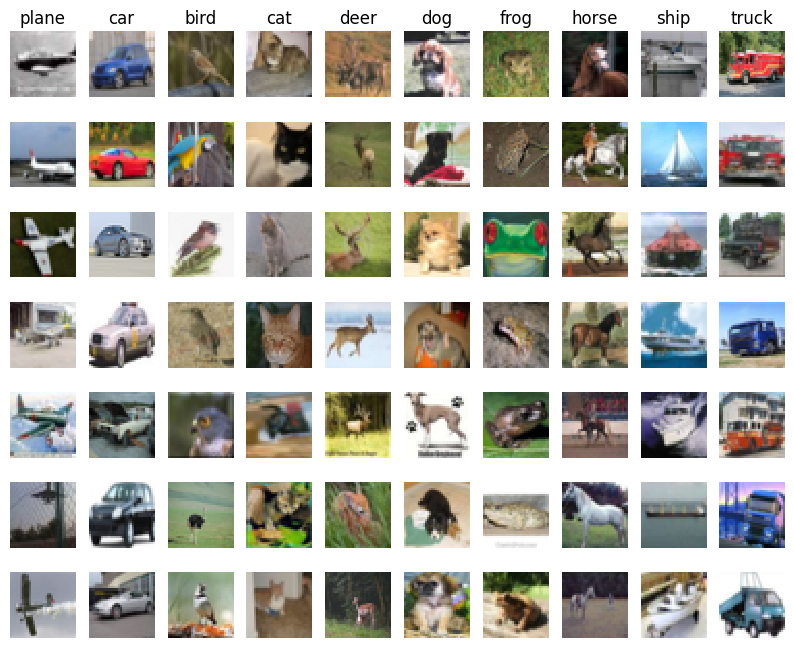

In [3]:
# Visualize some examples from the dataset.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):                      #enumerate(classes)遍历索引和元素,每次循环得到：y：类别编号（0~9）cls：类别名称（'plane', 'car', ...）
    idxs = np.flatnonzero(y_train == y)                #找到训练集里所有猫的图像的下标(满足非0)
    idxs = np.random.choice(idxs, samples_per_class, replace=False) 
    #idxs：当前类别的全部样本索引
    #size = samples_per_class：选 7 个
    #replace=False：不放回抽样（不重复）
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        #i 表示第几行（0~6） num_classes = 10 表示每行有 10 列   y表示第几列（0~9）  +1 因为 subplot 编号从 1 开始
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [4]:
# Subsample the data for more efficient code execution in this exercise
num_training = 5000
mask = list(range(num_training)) #这里mask是索引列表
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

# Reshape the image data into rows
#把a*b个数据展开成1*（a*b）的行向量
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
print(X_train.shape, X_test.shape)

(5000, 3072) (500, 3072)


In [5]:
from cs231n.classifiers import KNearestNeighbor

# Create a kNN classifier instance.
# Remember that training a kNN classifier is a noop:
# the Classifier simply remembers the data and does no further processing计算量发生在预测阶段，不是训练阶段
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

We would now like to classify the test data with the kNN classifier. Recall that we can break down this process into two steps:

1. First we must compute the distances between all test examples and all train examples.
2. Given these distances, for each test example we find the k nearest examples and have them vote for the label

Lets begin with computing the distance matrix between all training and test examples. For example, if there are **Ntr** training examples and **Nte** test examples, this stage should result in a **Nte x Ntr** matrix where each element (i,j) is the distance between the i-th test and j-th train example.

**Note: For the three distance computations that we require you to implement in this notebook, you may not use the np.linalg.norm() function that numpy provides.**

First, open `cs231n/classifiers/k_nearest_neighbor.py` and implement the function `compute_distances_two_loops` that uses a (very inefficient) double loop over all pairs of (test, train) examples and computes the distance matrix one element at a time.

In [6]:
# Open cs231n/classifiers/k_nearest_neighbor.py and implement
# compute_distances_two_loops.

# Test your implementation:
dists = classifier.compute_distances_two_loops(X_test)
print(dists.shape)

(500, 5000)


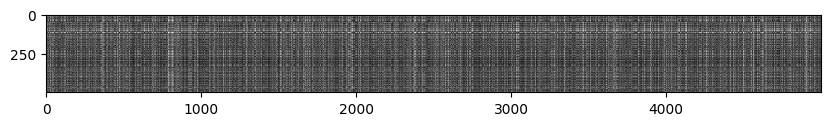

In [7]:
# We can visualize the distance matrix: each row is a single test example and
# its distances to training examples
#imshow 默认颜色映射里，数值越小颜色越暗
plt.imshow(dists, interpolation='none')
plt.show()

**Inline Question 1**

Notice the structured patterns in the distance matrix, where some rows or columns are visibly brighter. (Note that with the default color scheme black indicates low distances while white indicates high distances.)

- What in the data is the cause behind the distinctly bright rows?
- What causes the columns?

$\color{blue}{\textit Your Answer:}$ *亮行（白行）：表示某个测试样本与大多数训练样本距离都较大，通常说明该测试样本在原始像素空间中比较特殊（如亮度、背景、姿态、噪声异常等）。

亮列（白列）：表示某个训练样本与大多数测试样本距离都较大，通常说明该训练样本在原始像素空间中比较特殊或是离群样本。*



In [8]:
# Now implement the function predict_labels and run the code below:
# We use k = 1 (which is Nearest Neighbor).
y_test_pred = classifier.predict_labels(dists, k=1)

# Compute and print the fraction of correctly predicted examples
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


You should expect to see approximately `27%` accuracy. Now lets try out a larger `k`, say `k = 5`:

In [9]:
y_test_pred = classifier.predict_labels(dists, k=5)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 139 / 500 correct => accuracy: 0.278000


You should expect to see a slightly better performance than with `k = 1`.

**Inline Question 2**

We can also use other distance metrics such as L1 distance.
For pixel values $p_{ij}^{(k)}$ at location $(i,j)$ of some image $I_k$,

the mean $\mu$ across all pixels over all images is  全局均值  $$\mu=\frac{1}{nhw}\sum_{k=1}^n\sum_{i=1}^{h}\sum_{j=1}^{w}p_{ij}^{(k)}$$  
And the pixel-wise mean $\mu_{ij}$ across all images is  逐像素均值  
$$\mu_{ij}=\frac{1}{n}\sum_{k=1}^np_{ij}^{(k)}.$$
The general standard deviation $\sigma$ and pixel-wise standard deviation $\sigma_{ij}$ is defined similarly.

Which of the following preprocessing steps will not change the performance of a Nearest Neighbor classifier that uses L1 distance? Select all that apply. To clarify, <mark>both training and test examples are preprocessed in the same way.</mark>
波浪线（~） 表示：“经过变换后的量 / 预处理后的量”。
1. Subtracting the mean $\mu$ ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu$.)
2. Subtracting the per pixel mean $\mu_{ij}$  ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu_{ij}$.)
3. Subtracting the mean $\mu$ and dividing by the standard deviation $\sigma$.
4. Subtracting the pixel-wise mean $\mu_{ij}$ and dividing by the pixel-wise standard deviation $\sigma_{ij}$.
5. Rotating the coordinate axes of the data, which means rotating all the images by the same angle. Empty regions in the image caused by rotation are padded with a same pixel value and no interpolation is performed.

$\color{blue}{\textit Your Answer:}$    


$\color{blue}{\textit Your Explanation:}$
如果一个预处理对所有 train/test 都做同样变换，且满足下面之一，就通常不变：

平移（加/减固定量） 

整体统一缩放（乘/除同一个常数） 

坐标重排（permutation） 

会变的是：

不同维度缩放不同（每个像素除以不同数）

除$\sigma_{ij}$

每个像素位置除以不同的数 

这相当于给每个维度一个不同权重

<mark>预处理的目的?
预处理不是只是“清洗数据”，它很多时候其实是在重新定义几何空间:  
减均值：平移坐标原点  
除标准差：拉伸/压缩坐标轴  
逐像素标准化：每个轴不同拉伸(改变距离度量偏好)  
PCA/白化（你后面可能会学）：旋转 + 缩放坐标轴  
</mark>

In [ ]:
# Now lets speed up distance matrix computation by using partial vectorization
# with one loop. Implement the function compute_distances_one_loop and run the
# code below:
dists_one = classifier.compute_distances_one_loop(X_test)

# To ensure that our vectorized implementation is correct, we make sure that it
# agrees with the naive implementation. There are many ways to decide whether
# two matrices are similar; one of the simplest is the Frobenius norm. In case
# you haven't seen it before, the Frobenius norm of two matrices is the square
# root of the squared sum of differences of all elements; in other words, reshape
# the matrices into vectors and compute the Euclidean distance between them.
# naive implementation（朴素实现，也就是 two-loops）
#np.linalg.norm(..., ord='fro')

difference = np.linalg.norm(dists - dists_one, ord='fro')
print('One loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

Frobenius norm:衡量两个矩阵的差异
$difference = \sqrt{\sum_{i,j} (dists_{ij} - dists\_one_{ij})^2}$

In [19]:
# Now implement the fully vectorized version inside compute_distances_no_loops
# and run the code
dists_two = classifier.compute_distances_no_loops(X_test)

# check that the distance matrix agrees with the one we computed before:
difference = np.linalg.norm(dists - dists_two, ord='fro')
print('No loop difference was: %f' % (difference, ))
if difference < 0.001:
    print('Good! The distance matrices are the same')
else:
    print('Uh-oh! The distance matrices are different')

No loop difference was: 0.000000
Good! The distance matrices are the same


# Let's compare how fast the implementations are
def time_function(f, *args):
    """
    Call a function f with args and return the time (in seconds) that it took to execute.
    """
    import time
    tic = time.time()
    f(*args)
    toc = time.time()
    return toc - tic

two_loop_time = time_function(classifier.compute_distances_two_loops, X_test)
print('Two loop version took %f seconds' % two_loop_time)

one_loop_time = time_function(classifier.compute_distances_one_loop, X_test)
print('One loop version took %f seconds' % one_loop_time)

no_loop_time = time_function(classifier.compute_distances_no_loops, X_test)
print('No loop version took %f seconds' % no_loop_time)

# You should see significantly faster performance with the fully vectorized implementation!

# NOTE: depending on what machine you're using,
# you might not see a speedup when you go from two loops to one loop,
# and might even see a slow-down.

在 kNN 距离计算中，`two-loops` 版本虽然有两层 Python 循环，但每次只处理一对样本、计算一个标量距离（相减、平方求和、开根号并写入 `dists[i,j]`），单次开销较小；`one-loop` 版本每次会对一个测试样本与全部训练样本一起计算，虽然少了一层循环，但会反复创建和处理形状为 `(num_train, D)` 的大临时数组（如 `self.X_train - X[i]`、平方、按行求和等），因此可能因为内存分配和读写开销更大而在某些环境下反而更慢；而 `no-loops` 版本通过矩阵乘法（如 `X.dot(self.X_train.T)`）和广播把主要计算交给 NumPy 底层优化库（BLAS/MKL/OpenBLAS），能显著减少 Python 层开销，因此通常会带来数量级的速度提升。

### Cross-validation

We have implemented the k-Nearest Neighbor classifier but we set the value k = 5 arbitrarily. We will now determine the best value of this hyperparameter with cross-validation.

In [25]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = []
y_train_folds = []
################################################################################
# TODO:                                                                        #
# Split up the training data into folds. After splitting, X_train_folds and    #
# y_train_folds should each be lists of length num_folds, where                #
# y_train_folds[i] is the label vector for the points in X_train_folds[i].     #
# Hint: Look up the numpy array_split function.  
#numpy array_split function:切为几份，每份还是Numpy数组
################################################################################

#soulution
X_train_folds = np.array_split(X_train,num_folds)
y_train_folds = np.array_split(y_train,num_folds)
#solution

# A dictionary holding the accuracies for different values of k that we find
# when running cross-validation. After running cross-validation,
# k_to_accuracies[k] should be a list of length num_folds giving the different
# accuracy values that we found when using that value of k.
k_to_accuracies = {}

################################################################################
# TODO:                                                                        #
# Perform k-fold cross validation to find the best value of k. For each        #
# possible value of k, run the k-nearest-neighbor algorithm num_folds times,   #
# where in each case you use all but one of the folds as training data and the #
# last fold as a validation set. Store the accuracies for all fold and all     #
# values of k in the k_to_accuracies dictionary.                               #
################################################################################

#solution
#step 1

for k in k_choices:
    k_to_accuracies[k] = []
    for i in range(num_folds): #i表示第几组
        X_val = X_train_folds[i]
        y_val = y_train_folds[i]

        X_tr = np.concatenate(X_train_folds[:i] + X_train_folds[i+1:], axis=0)
        y_tr = np.concatenate(y_train_folds[:i] + y_train_folds[i+1:], axis=0)

#从 folds 列表里取出第 i 折，作为验证集（validation set） X_val：验证数据    y_val：验证标签
#举例（假设每折1000个样本）X_val.shape 可能是 (1000, 3072) y_val.shape 可能是 (1000,)
#X_train_folds[:i] 是什么？ 这是列表切片，表示“第 i组前面的所有(不包括第i）”。
#X_train_folds[i+1:] 是什么？ 表示“第 i 组后面的所有组(不包括第i）”。
#X_train_folds[:i] + X_train_folds[i+1:] 是什么？ 除第i组外的所有组
#np.concatenate(..., axis=0) 的作用是：沿着第0维（样本维度）把4折拼起来 例如把四个 (1000, 3072) 拼成：(4000, 3072)
#取第 i 折作为验证集，把其余折拼成训练集，这两步的意义非常核心，本质上是在做一件事：
#模拟“拿一部分数据训练、拿没见过的数据验证”的过程，并且把这件事轮流做很多次，让评估更稳。

#step 2
        classifier = KNearestNeighbor()
        classifier.train(X_tr, y_tr)
        y_val_pred = classifier.predict(X_val, k=k, num_loops=0)

        num_correct = np.sum(y_val_pred == y_val)
        accuracy = num_correct/len(y_val)
        k_to_accuracies[k].append(accuracy)

#y_val_pred == y_val  逐元素比较预测标签和真实标签： 预测对 → True  预测错 → False
#得到一个布尔数组，例如：[True, False, True, True, ...]


#solution


# Print out the computed accuracies
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.263000
k = 1, accuracy = 0.257000
k = 1, accuracy = 0.264000
k = 1, accuracy = 0.278000
k = 1, accuracy = 0.266000
k = 3, accuracy = 0.239000
k = 3, accuracy = 0.249000
k = 3, accuracy = 0.240000
k = 3, accuracy = 0.266000
k = 3, accuracy = 0.254000
k = 5, accuracy = 0.248000
k = 5, accuracy = 0.266000
k = 5, accuracy = 0.280000
k = 5, accuracy = 0.292000
k = 5, accuracy = 0.280000
k = 8, accuracy = 0.262000
k = 8, accuracy = 0.282000
k = 8, accuracy = 0.273000
k = 8, accuracy = 0.290000
k = 8, accuracy = 0.273000
k = 10, accuracy = 0.265000
k = 10, accuracy = 0.296000
k = 10, accuracy = 0.276000
k = 10, accuracy = 0.284000
k = 10, accuracy = 0.280000
k = 12, accuracy = 0.260000
k = 12, accuracy = 0.295000
k = 12, accuracy = 0.279000
k = 12, accuracy = 0.283000
k = 12, accuracy = 0.280000
k = 15, accuracy = 0.252000
k = 15, accuracy = 0.289000
k = 15, accuracy = 0.278000
k = 15, accuracy = 0.282000
k = 15, accuracy = 0.274000
k = 20, accuracy = 0.270000
k = 20, accu

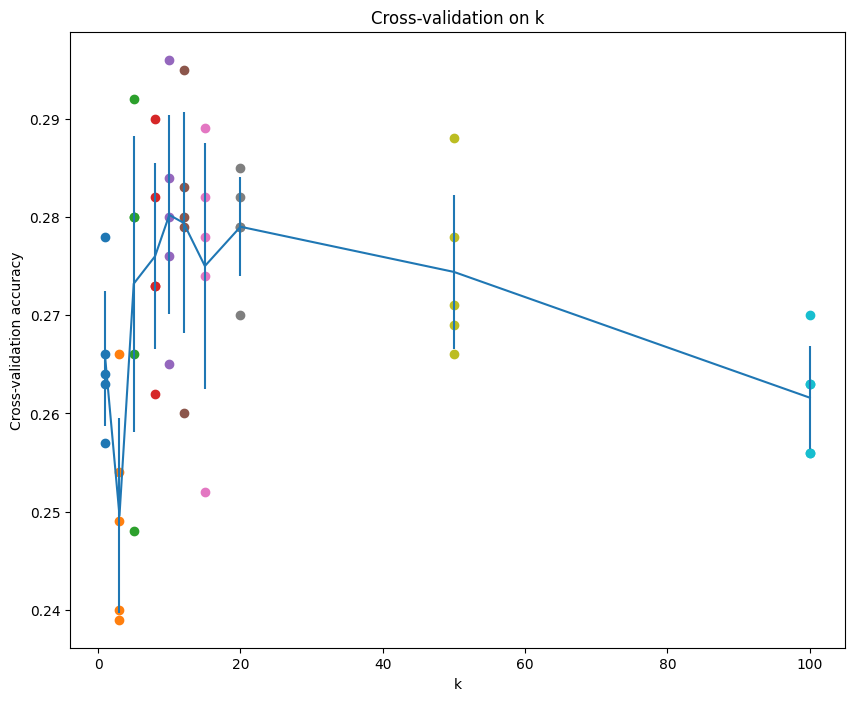

In [26]:
# plot the raw observations
for k in k_choices:
    accuracies = k_to_accuracies[k]
    plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('Cross-validation on k')
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.show()

In [27]:
# Based on the cross-validation results above, choose the best value for k,
# retrain the classifier using all the training data, and test it on the test
# data. You should be able to get above 28% accuracy on the test data.
best_k = 1

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


**Inline Question 3**

Which of the following statements about $k$-Nearest Neighbor ($k$-NN) are true in a classification setting, and for all $k$? Select all that apply.
1. The decision boundary of the k-NN classifier is linear.
2. The training error of a 1-NN will always be lower than or equal to that of 5-NN.
3. The test error of a 1-NN will always be lower than that of a 5-NN.
4. The time needed to classify a test example with the k-NN classifier grows with the size of the training set.
5. None of the above.

$\color{blue}{\textit Your Answer:}$
$\color{blue}{\textit Your Explanation:}$
1. (False)k-NN 的分类规则是：看测试点周围最近的 k 个训练样本，多数投票决定类别，这会导致决策边界高度依赖训练样本的分布。  
2. (True)在训练集上评估时，对某个训练样本 在 1-NN 中，它的最近邻通常就是它自己（距离为 0）所以它会被预测成自己的标签（通常正确）
3. (False)太绝对了。常见情况（直觉）1-NN：对噪声敏感，方差大，容易过拟合 5-NN：更平滑一些，抗噪声更好，有时泛化更好
4. (True)
5. (False)